In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder

df=pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         100 non-null    int64  
 1   Age                 90 non-null     float64
 2   Gender              100 non-null    object 
 3   Department          90 non-null     object 
 4   Education           90 non-null     object 
 5   Experience_Years    100 non-null    int64  
 6   Monthly_Salary      90 non-null     float64
 7   Performance_Rating  100 non-null    int64  
 8   City                90 non-null     object 
 9   Attrition           100 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 7.9+ KB


In [66]:
#checking null or not
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [67]:
df['Age_mean_imputed']=df['Age'].fillna(df['Age'].mean())
df['Mon_Sal_mean_imputed']=df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())

In [68]:
df['City_mode_imputed']=df['City'].fillna(df['City'].mode()[0])
df['Dept_mode_imputed']=df['Department'].fillna(df['Department'].mode()[0])
df['Education_mode_imputed']=df['Education'].fillna(df['Education'].mode()[0])


/tmp/ipykernel_3157/1018381613.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Department',y='Employee_ID',palette='pastel')


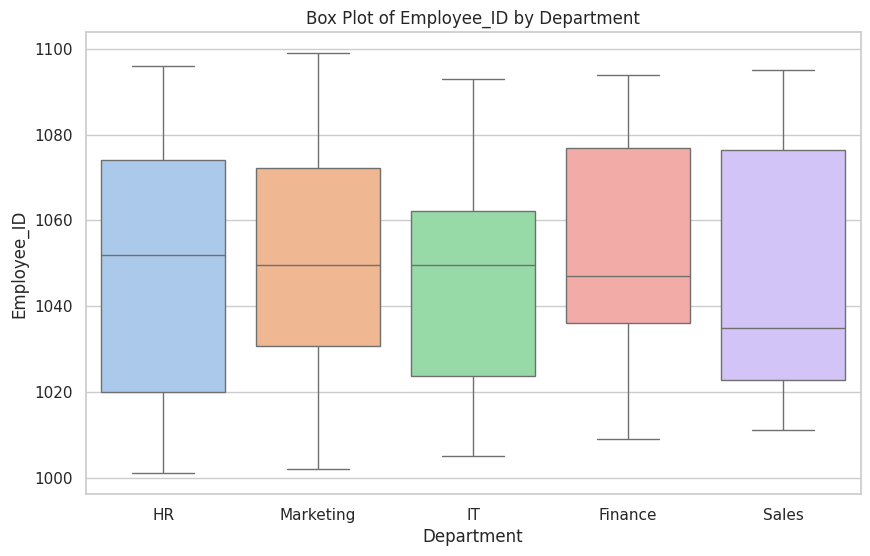

In [77]:
#Box Plot

sns.set(style="whitegrid")

#create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x='Department',y='Employee_ID',palette='pastel')

#set plot title and labels
plt.title('Box Plot of Employee_ID by Department',fontsize=12)
plt.xlabel('Department',fontsize=12)
plt.ylabel('Employee_ID',fontsize=12)

#show plot
plt.show()

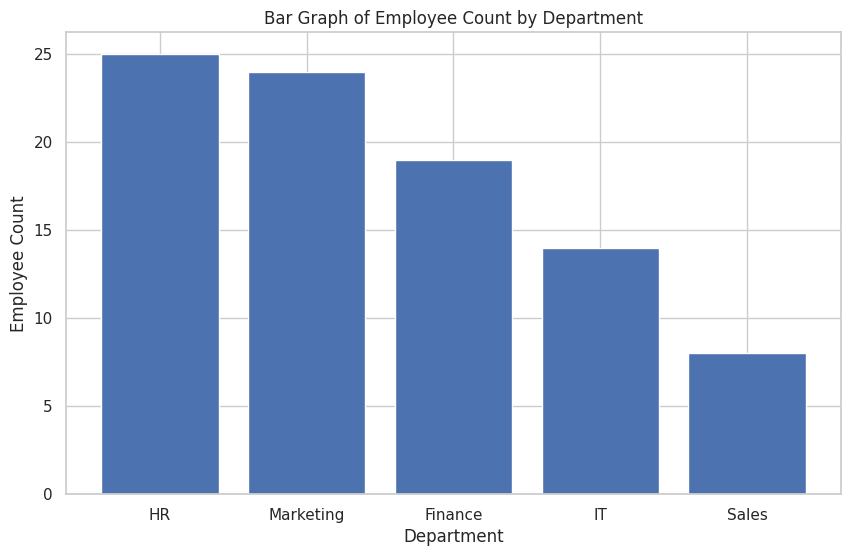

In [70]:
# Bar Graph using pure Matplotlib

# Calculate the counts for each department
dept_counts = df['Department'].value_counts()

# create bar graph
plt.figure(figsize=(10, 6))
plt.bar(x=dept_counts.index, height=dept_counts.values)

# set plot title and labels
plt.title('Bar Graph of Employee Count by Department', fontsize=12)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Employee Count', fontsize=12)

# show plot
plt.show()

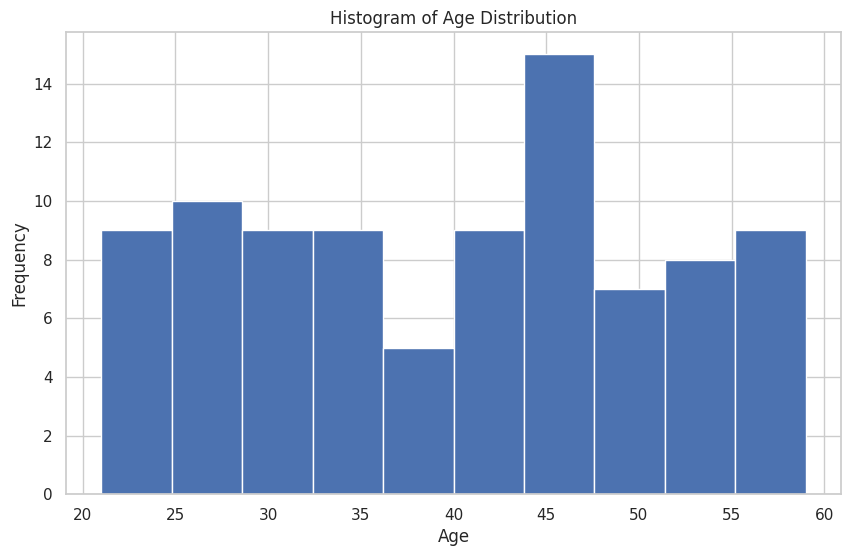

In [71]:
# Histogram using pure Matplotlib

# create histogram
plt.figure(figsize=(10, 6))
plt.hist(x=df['Age'].dropna())

# set plot title and labels
plt.title('Histogram of Age Distribution', fontsize=12)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# show plot
plt.show()

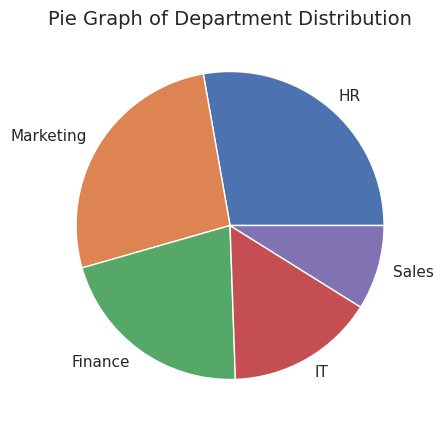

In [72]:
dept_counts = df['Department'].value_counts()

# 2. Create the pie chart
plt.figure(figsize=(5,5))
plt.pie(x=dept_counts.values,labels=dept_counts.index)

# 3. Add a title
plt.title('Pie Graph of Department Distribution', fontsize=14)

# 4. Show the chart
plt.show()

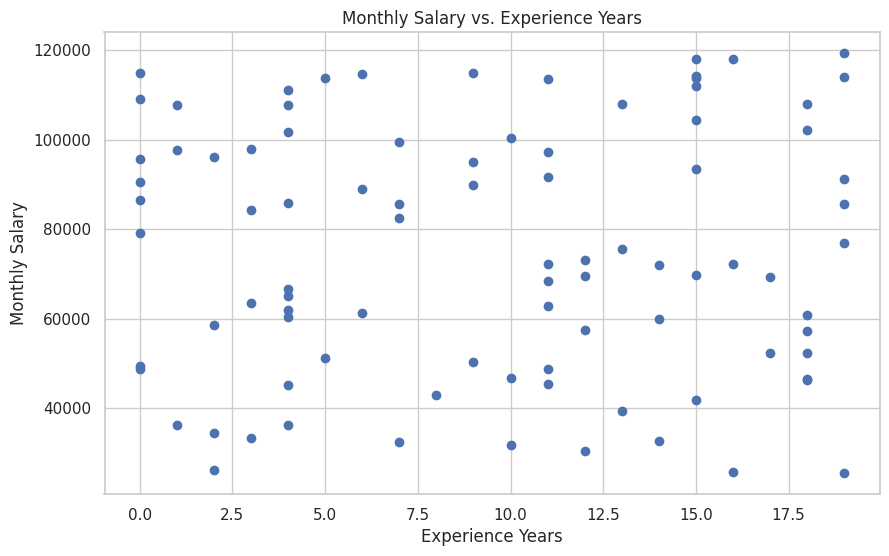

In [73]:
# Create dot graph
plt.figure(figsize=(10, 6))
plt.scatter(x=df['Experience_Years'], y=df['Monthly_Salary'])

# Add title
plt.title('Monthly Salary vs. Experience Years')
plt.xlabel('Experience Years')
plt.ylabel('Monthly Salary')

plt.show()

In [74]:
label_encoder=LabelEncoder()
df['Gender_Label']=label_encoder.fit_transform(df['Gender'])

In [75]:
one_hot_encoded_data=pd.get_dummies(df['Department'],prefix='Department')
df=pd.concat([df,one_hot_encoded_data],axis=1)

In [76]:
df

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,Age_mean_imputed,Mon_Sal_mean_imputed,City_mode_imputed,Dept_mode_imputed,Education_mode_imputed,Gender_Label,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,59.0,52350.0,Calicut,HR,Masters,1,False,True,False,False,False
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,49.0,118008.0,Chennai,Marketing,Bachelors,0,False,False,False,True,False
2,1003,35.0,Female,HR,NaN,19,119297.0,1,Kochi,Yes,35.0,119297.0,Kochi,HR,Masters,0,False,True,False,False,False
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,28.0,50351.0,Trivandrum,HR,PhD,0,False,True,False,False,False
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,41.0,113668.0,Trivandrum,IT,Bachelors,1,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,54.0,48625.0,Chennai,HR,Masters,0,False,True,False,False,False
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,53.0,107873.0,Trivandrum,Marketing,Masters,1,False,False,False,True,False
97,1098,43.0,Male,NaN,PhD,1,97592.0,3,Chennai,No,43.0,97592.0,Chennai,HR,PhD,1,False,False,False,False,False
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,44.0,102052.0,Calicut,Marketing,PhD,0,False,False,False,True,False
